# TEC103 温控器控制示例

本示例演示如何使用 `tec_controller` 包控制光测未来 TEC103 温控器。

## 前提条件
- TEC103 温控器已通过 USB-TTL 或 RS485 连接到电脑
- 虚拟环境 `agent_exp_env` 已配置好依赖（`pip install pyserial`）
- 在 VSCode 中打开此 notebook 后，右上角选择内核 `Python (agent_exp_env)`

In [1]:
# 设置项目根目录
from pathlib import Path
project_root = Path.cwd().parent

In [2]:
from tec_controller import TECInstrument
import time
import matplotlib.pyplot as plt
import numpy as np
print("模块导入成功")

模块导入成功


---
## 1. 建立连接

> **注意**: 以下代码需要连接 TEC103 硬件才能运行。
请根据实际情况修改串口号 `PORT`。

In [3]:
# 请替换为实际的串口号
PORT = "COM3"  # Windows
# PORT = "/dev/ttyUSB0"  # Linux
# PORT = "/dev/cu.usbserial-XXXX"  # macOS

try:
    tec = TECInstrument(port=PORT)
    tec.connect()
    print(f"已连接 TEC103 ({PORT})")
except Exception as e:
    print(f"连接失败: {e}")
    print("后续示例将使用模拟/脱机模式说明")

已连接 TEC103 (COM3)


## 2. 查询设备信息

In [4]:
if tec.connected:
    model_code = tec.get_model()
    fw = tec.get_firmware_version()
    print(f"温控器型号代码: {model_code}")
    print(f"固件版本: {fw}")
    print(f"错误代码: {tec.get_error_code()}")
else:
    print("未连接硬件，跳过")

温控器型号代码: 103
固件版本: 4.2.9
错误代码: 0


---
## 3. 设置目标温度

温控器内部使用整数表示温度，缩放系数为 100000：
- `2500000` 对应 25.00000 ℃
- 分辨率 0.00001 ℃
- 范围 -400.00000 ~ 1000.00000 ℃

In [6]:
if tec.connected:
    # 设置目标温度为 95.0 ℃
    tec.set_target_temperature(100.0, channel=1)
    
    # 读取确认
    tg = tec.get_target_temperature(channel=1)
    print(f"目标温度: {tg:.5f} ℃")
else:
    print("未连接硬件，跳过")

目标温度: 100.00000 ℃


---
## 4. 查询当前温度

读取当前实际温度、传感器电阻值。

In [9]:
if tec.connected:
    temp = tec.get_temperature(channel=1)
    res = tec.get_resistance(channel=1)
    print(f"当前温度: {temp:.5f} ℃")
    print(f"传感器电阻: {res:.6f} kΩ")
else:
    print("未连接硬件，跳过")

当前温度: 99.99110 ℃
传感器电阻: 697711.148000 kΩ


## 5. 一次性查询关键数据

`DATADEMAND` 指令可以一次性返回各通道温度、电阻、输出电压等关键数据。

In [10]:
if tec.connected:
    all_data = tec.get_all_temperatures()
    print("各通道温度:")
    for key, val in all_data.items():
        if key == "internal":
            print(f"  温控器自身温度: {val} ℃")
        else:
            print(f"  {key.upper():6s}: {val:.5f} ℃")
else:
    print("未连接硬件，跳过")

各通道温度:
  TC1   : 99.99434 ℃
  温控器自身温度: 35 ℃


---
## 6. 设置输出使能

使能或关闭温控器输出。
- `enable=True`：使能输出电压
- `enable=False`：关闭输出电压

In [11]:
if tec.connected:
    # 使能输出
    tec.set_enable(False, channel=1)
    status = tec.get_enable(channel=1)
    print(f"输出使能状态: {'已使能' if status else '已关闭'}")
    
    time.sleep(1)
    
    # 关闭输出
    tec.set_enable(True, channel=1)
    status = tec.get_enable(channel=1)
    print(f"输出使能状态: {'已使能' if status else '已关闭'}")
else:
    print("未连接硬件，跳过")

输出使能状态: 已关闭
输出使能状态: 已使能


---
## 7. 温度设定-监测循环（PID 控温演示）

连续监测温度变化曲线，演示闭环控温过程。

> ⚠️ 需要先连接好 TEC 负载和温度传感器，并确保散热条件良好。

目标温度: 100.0 ℃
正在监测温度变化 (30 秒)...
  [ 5s] 当前温度: 93.030 ℃
  [10s] 当前温度: 95.189 ℃
  [15s] 当前温度: 97.312 ℃
  [20s] 当前温度: 98.753 ℃
  [25s] 当前温度: 99.827 ℃
  [30s] 当前温度: 100.418 ℃


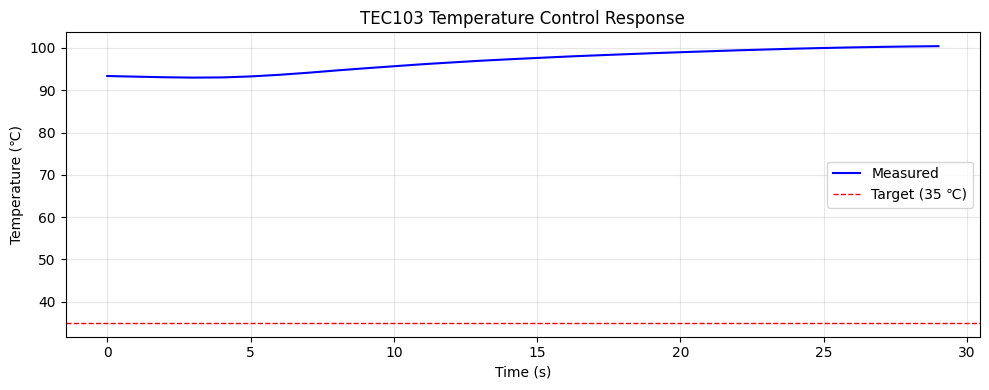

曲线已保存至: d:\Code\exp_agent\results\tec103_control_response.png


In [13]:
if tec.connected:
    # 记录温度曲线
    temps = []
    duration = 30  # 监测 30 秒
    interval = 1    # 每秒记录一次
    
    tec.set_target_temperature(100.0, channel=1)
    tec.set_enable(True, channel=1)
    
    print(f"目标温度: 100.0 ℃")
    print(f"正在监测温度变化 ({duration} 秒)...")
    
    for i in range(duration):
        t = tec.get_temperature(channel=1)
        temps.append(t)
        if (i + 1) % 5 == 0:
            print(f"  [{i+1:2d}s] 当前温度: {t:.3f} ℃")
        time.sleep(interval)
    
    tec.set_enable(False, channel=1)
    
    # 绘制温度曲线
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.arange(len(temps)), temps, "b-", lw=1.5, label="Measured")
    ax.axhline(y=35.0, color="r", ls="--", lw=1, label="Target (35 ℃)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature (℃)")
    ax.set_title("TEC103 Temperature Control Response")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    plot_path = project_root / "results" / "tec103_control_response.png"
    fig.savefig(str(plot_path), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"曲线已保存至: {plot_path}")
else:
    # 无硬件时展示模拟数据
    print("未连接硬件，使用模拟数据展示温度曲线")
    t_sim = np.arange(0, 30)
    temp_sim = 25 + 10 * (1 - np.exp(-t_sim / 8)) + np.random.randn(len(t_sim)) * 0.1
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_sim, temp_sim, "b-", lw=1.5, label="Simulated")
    ax.axhline(y=35.0, color="r", ls="--", lw=1, label="Target (35 ℃)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature (℃)")
    ax.set_title("TEC103 Temperature Control Response (Simulated)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## 8. PID 参数配置

温控器 PID 参数范围：
- P (比例): 0 ~ 9000000
- I (积分): 0 ~ 9000000
- D (微分): 0 ~ 9000000

也可以启用 PID 自整定功能使温控器自动优化参数。

In [16]:
if tec.connected:
    # 读取当前 PID 参数
    kp = tec.get_kp(channel=1)
    ki = tec.get_ki(channel=1)
    kd = tec.get_kd(channel=1)
    print(f"当前 PID 参数: P={kp}, I={ki}, D={kd}")
    
    # 设置 PID 参数
    tec.set_pid(kp=kp, ki=ki, kd=kd, channel=1)
    print(f"当前 PID 参数: P={kp}, I={ki}, D={kd}")
else:
    print("未连接硬件，跳过")

当前 PID 参数: P=200, I=30, D=300
当前 PID 参数: P=200, I=30, D=300


---
## 9. 常用配置组合

一个完整的温控启停流程。

In [ ]:
if tec.connected:
    # 启动温控
    print("=== 启动温控 ===")
    tec.set_output_mode(0, channel=1)          # 双向模式
    tec.set_max_duty(80, channel=1)            # 最大输出 80%
    tec.set_slope(1.0, channel=1)              # 斜率限制 1℃/s
    tec.set_target_temperature(25.0, channel=1) # 目标 25℃
    tec.set_enable(True, channel=1)             # 使能输出
    print("温控已启动 (目标 25℃, 双向模式)")
    
    time.sleep(2)
    
    # 读取当前状态
    print(f"  目标温度: {tec.get_target_temperature():.3f} ℃")
    print(f"  当前温度: {tec.get_temperature():.3f} ℃")
    print(f"  输出使能: {tec.get_enable()}")
    print(f"  输出模式: {tec.get_output_mode()}")
    
    # 停止温控
    tec.set_enable(False, channel=1)
    print("温控已停止")
else:
    print("未连接硬件，跳过")

---
## 10. 断开连接

In [ ]:
if tec.connected:
    tec.disconnect()
    print("串口已关闭")
else:
    print("无活动连接")